# 🏠 House Prices — 05. Regras de Associação e Detecção de Outliers
**Responsável:** Alessandro  
**Dataset:** [Kaggle - House Prices: Advanced Regression Techniques](https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data)  
**Objetivo:** Aplicar técnicas de aprendizagem não supervisionada (Apriori para associação e LOF para detecção de anomalias).

---
## 📦 0. Setup — Importações e Configurações

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Paleta e estilo
BLUE   = "#2563EB"
ORANGE = "#F97316"
RED    = "#EF4444"
GREEN  = "#22C55E"
PURPLE = "#A855F7"
GRAY   = "#6B7280"
BG     = "#F8FAFC"
DARK   = "#1E293B"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor":   BG,
    "axes.edgecolor":   DARK,
    "axes.labelcolor":  DARK,
    "text.color":       DARK,
})

---
## 📂 1. Carregamento dos Dados

Carregamos a base original (`train.csv`) para manter os valores em escalas reais (ex: dólares, pés quadrados), o que torna as regras de associação geradas pelo Apriori compreensíveis para humanos.

In [2]:
df = pd.read_csv("../data/train.csv")
print(f"Shape original: {df.shape}")

Shape original: (1460, 81)


---
## 🔗 2. Regras de Associação (Algoritmo Apriori)

O algoritmo Apriori exige variáveis binárias/transacionais. Abaixo, transformamos features numéricas e categóricas em tags lógicas (ex: `HighQual`, `PriceHigh`, `BigHouse`).

In [3]:
def binarize(df):
    items = []
    items.append(("HighQual",    df["OverallQual"] >= 7))
    items.append(("LowQual",     df["OverallQual"] <= 4))
    
    q33 = df["SalePrice"].quantile(0.33)
    q66 = df["SalePrice"].quantile(0.66)
    items.append(("PriceHigh",   df["SalePrice"] >= q66))
    items.append(("PriceMid",    (df["SalePrice"] >= q33) & (df["SalePrice"] < q66)))
    items.append(("PriceLow",    df["SalePrice"] < q33))
    
    items.append(("HasGarage",   df["GarageArea"] > 0))
    items.append(("BigGarage",   df["GarageArea"] >= 600))
    items.append(("HasBsmt",     df["TotalBsmtSF"] > 0))
    items.append(("BigBsmt",     df["TotalBsmtSF"] >= 1000))
    items.append(("BigHouse",    df["GrLivArea"] >= 2000))
    items.append(("SmallHouse",  df["GrLivArea"] < 1200))
    items.append(("MultiBath",   df["FullBath"] >= 2))
    items.append(("HasFireplace",df["Fireplaces"] > 0))
    items.append(("CentralAC",   df["CentralAir"] == "Y"))
    items.append(("GoodKitchen", df["KitchenQual"].isin(["Gd","Ex"])))
    items.append(("Remodeled",   df["YearRemodAdd"] > df["YearBuilt"]))
    items.append(("NewHouse",    df["YearBuilt"] >= 2000))
    
    top_nb = df.groupby("Neighborhood")["SalePrice"].median().nlargest(5).index
    items.append(("PremiumNbhd", df["Neighborhood"].isin(top_nb)))
    items.append(("PavedDrive",  df["PavedDrive"] == "Y"))
    
    result = pd.DataFrame({name: series.astype(bool) for name, series in items})
    return result

bin_df = binarize(df)
print("Base Binarizada:", bin_df.shape)

freq_items = apriori(bin_df, min_support=0.05, use_colnames=True, max_len=3)
rules = association_rules(freq_items, metric="lift", min_threshold=1.2)
rules = rules.sort_values("lift", ascending=False)
print(f"Total de regras encontradas: {len(rules)}")

Base Binarizada: (1460, 19)
Total de regras encontradas: 1728


✅ Gráfico de Regras de Associação salvo em plots/associacao_regras.png


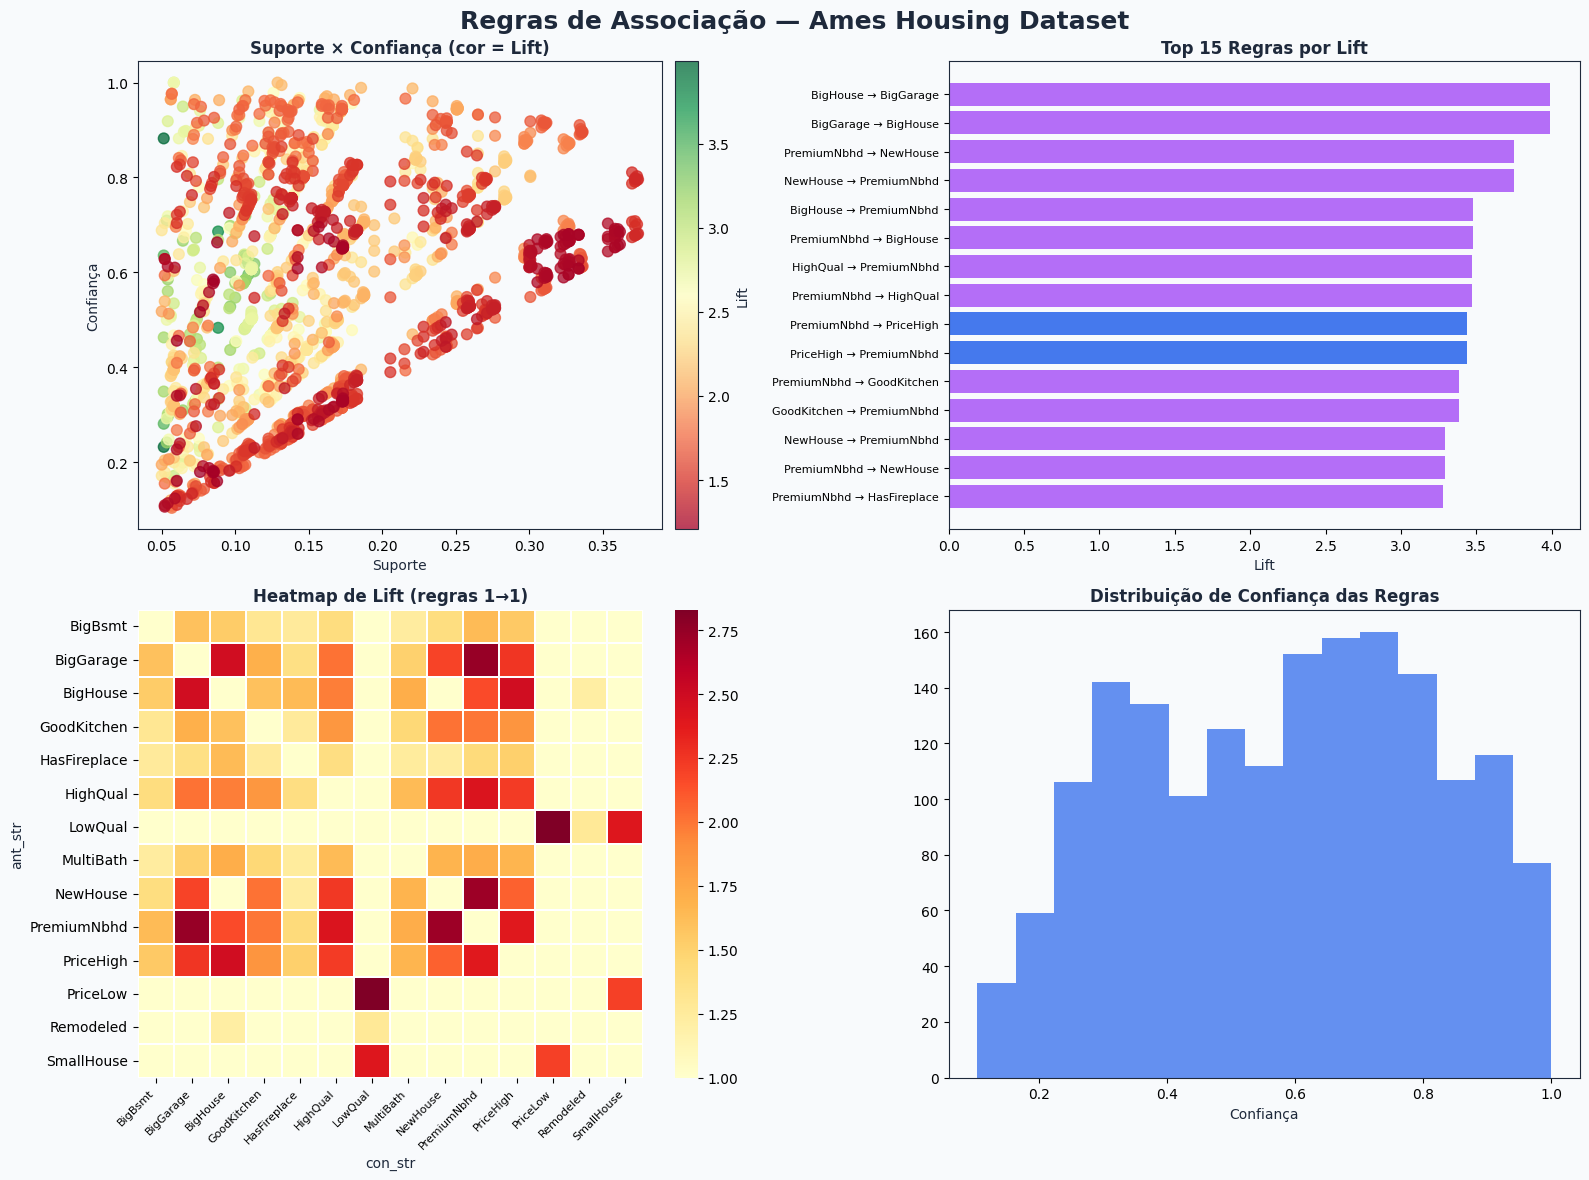

In [4]:
os.makedirs("../plots", exist_ok=True)
fig1, axes = plt.subplots(2, 2, figsize=(16, 12))
fig1.suptitle("Regras de Associação — Ames Housing Dataset", fontsize=18, fontweight="bold", y=0.98)

ax = axes[0,0]
sc = ax.scatter(rules["support"], rules["confidence"], c=rules["lift"], cmap="RdYlGn", s=60, alpha=0.75)
cb = fig1.colorbar(sc, ax=ax, pad=0.02)
cb.set_label("Lift", fontsize=10)
ax.set_xlabel("Suporte")
ax.set_ylabel("Confiança")
ax.set_title("Suporte × Confiança (cor = Lift)", fontweight="bold")

ax = axes[0,1]
top15 = rules.head(15).copy()
top15["rule"] = [f"{list(a)[0]} → {list(c)[0]}" for a, c in zip(top15["antecedents"], top15["consequents"])]
colors = [BLUE if "PriceHigh" in r else ORANGE if "PriceLow" in r else PURPLE for r in top15["rule"]]
bars = ax.barh(range(len(top15)), top15["lift"], color=colors, alpha=0.85)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15["rule"], fontsize=8)
ax.set_xlabel("Lift")
ax.set_title("Top 15 Regras por Lift", fontweight="bold")
ax.invert_yaxis()

ax = axes[1,0]
simple = rules[rules["antecedents"].apply(len)==1 & (rules["consequents"].apply(len)==1)].copy()
simple["ant_str"] = simple["antecedents"].apply(lambda x: list(x)[0])
simple["con_str"] = simple["consequents"].apply(lambda x: list(x)[0])
pivot = simple.pivot_table(index="ant_str", columns="con_str", values="lift", aggfunc="max")
pivot = pivot.fillna(1.0)
sns.heatmap(pivot, ax=ax, cmap="YlOrRd", linewidths=0.3)
ax.set_title("Heatmap de Lift (regras 1→1)", fontweight="bold")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)

ax = axes[1,1]
ax.hist(rules["confidence"], bins=15, alpha=0.7, color=BLUE)
ax.set_xlabel("Confiança")
ax.set_title("Distribuição de Confiança das Regras", fontweight="bold")

fig1.tight_layout()
fig1.savefig("../plots/associacao_regras.png", dpi=150, bbox_inches="tight")
print("✅ Gráfico de Regras de Associação salvo em plots/associacao_regras.png")
plt.show()

---
## 👾 3. Detecção de Outliers (Local Outlier Factor - LOF)

Utilizamos o algoritmo LOF para encontrar anomalias baseadas na densidade local dos imóveis.

In [5]:
num_cols = ["GrLivArea","TotalBsmtSF","GarageArea","LotArea",
            "OverallQual","OverallCond","YearBuilt","SalePrice",
            "1stFlrSF","TotRmsAbvGrd","Fireplaces","GarageCars"]

X = df[num_cols].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
labels = lof.fit_predict(X_scaled)
scores = -lof.negative_outlier_factor_

df["lof_score"] = scores
df["is_outlier"] = labels == -1
n_out = df["is_outlier"].sum()

print(f"Outliers detectados pelo LOF: {n_out} ({n_out/len(df):.1%})")

Outliers detectados pelo LOF: 73 (5.0%)


✅ Gráfico de Outliers salvo em plots/outliers_lof.png


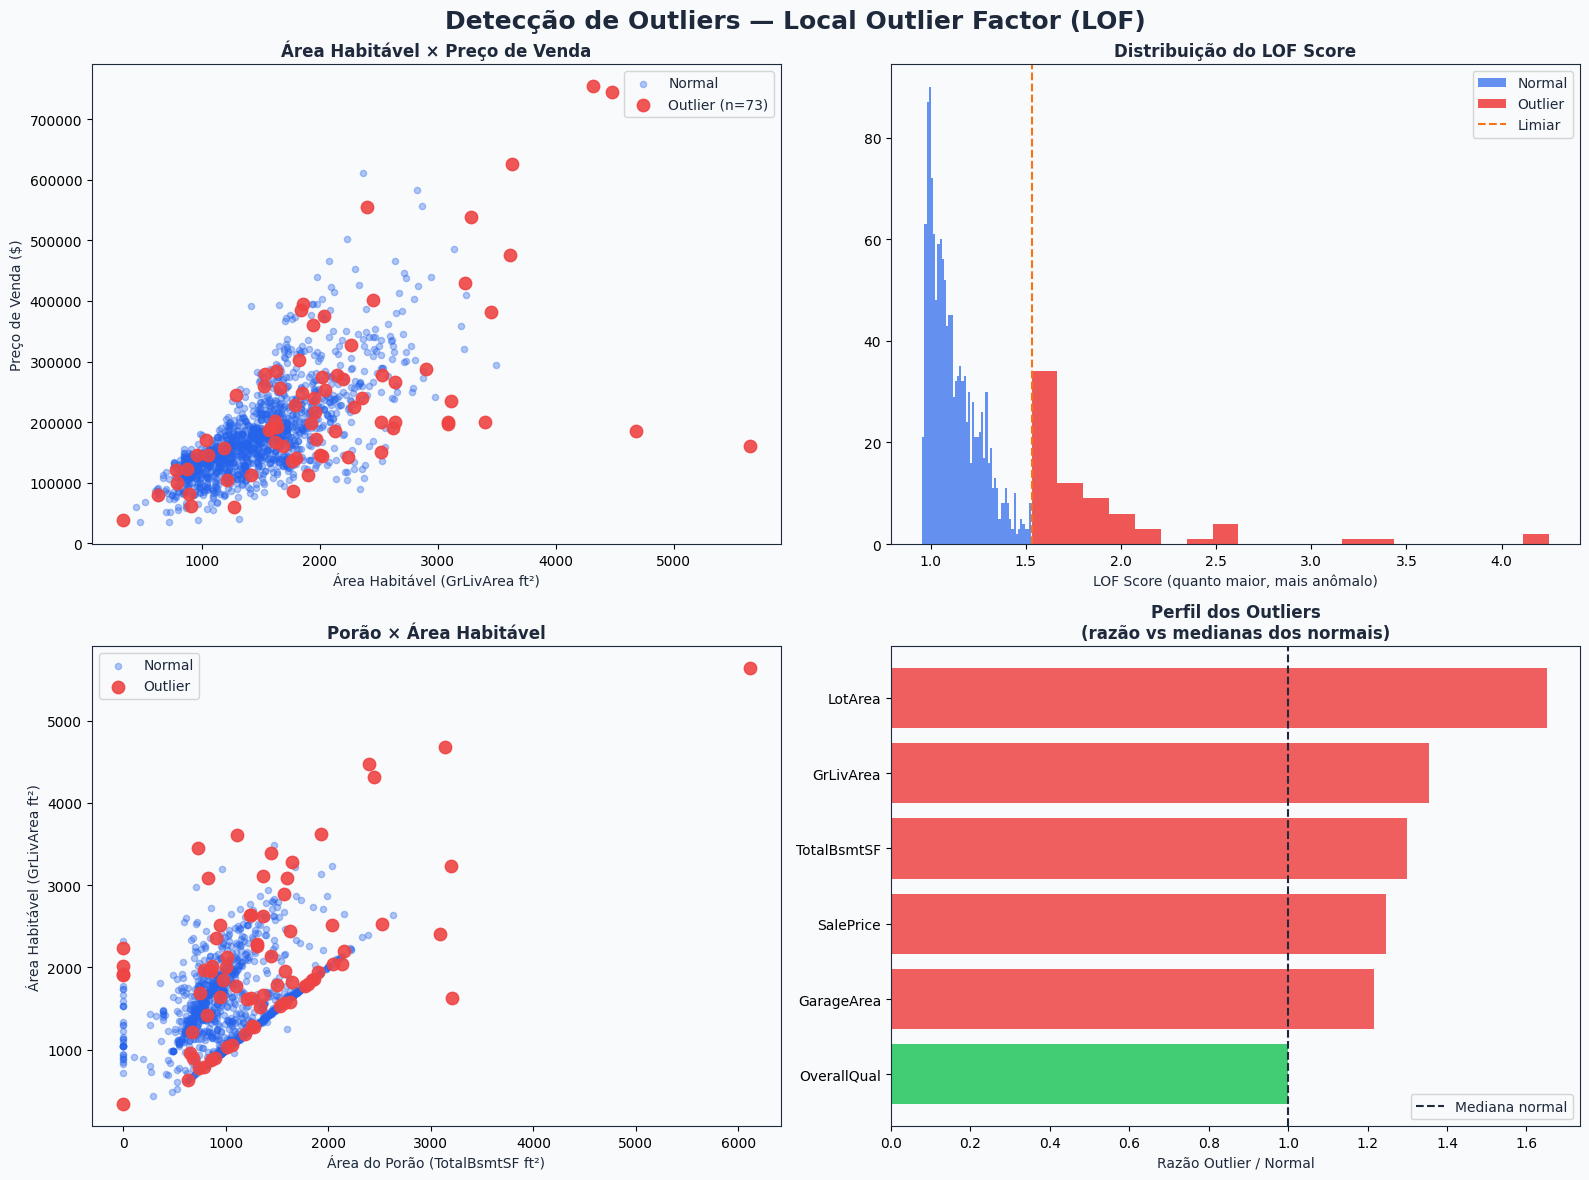

In [6]:
fig2, axes = plt.subplots(2, 2, figsize=(16, 12))
fig2.suptitle("Detecção de Outliers — Local Outlier Factor (LOF)", fontsize=18, fontweight="bold", y=0.98)

normal  = df[~df["is_outlier"]]
outlier = df[df["is_outlier"]]

# 2a) GrLivArea vs SalePrice
ax = axes[0,0]
ax.scatter(normal["GrLivArea"],  normal["SalePrice"],  s=20, alpha=0.35, color=BLUE, label="Normal")
ax.scatter(outlier["GrLivArea"], outlier["SalePrice"], s=80, alpha=0.9,  color=RED,  label=f"Outlier (n={n_out})", zorder=5)
ax.set_xlabel("Área Habitável (GrLivArea ft²)")
ax.set_ylabel("Preço de Venda ($)")
ax.set_title("Área Habitável × Preço de Venda", fontweight="bold")
ax.legend()

# 2b) Distribuição do LOF score
ax = axes[0,1]
ax.hist(normal["lof_score"],  bins=50, color=BLUE, alpha=0.7, label="Normal")
ax.hist(outlier["lof_score"], bins=20, color=RED,  alpha=0.9, label="Outlier")
ax.axvline(outlier["lof_score"].min(), color=ORANGE, ls="--", lw=1.5, label="Limiar")
ax.set_xlabel("LOF Score (quanto maior, mais anômalo)")
ax.set_title("Distribuição do LOF Score", fontweight="bold")
ax.legend()

# 2c) TotalBsmtSF vs GrLivArea
ax = axes[1,0]
ax.scatter(normal["TotalBsmtSF"],  normal["GrLivArea"],  s=20, alpha=0.35, color=BLUE, label="Normal")
ax.scatter(outlier["TotalBsmtSF"], outlier["GrLivArea"], s=80, alpha=0.9,  color=RED,  label="Outlier", zorder=5)
ax.set_xlabel("Área do Porão (TotalBsmtSF ft²)")
ax.set_ylabel("Área Habitável (GrLivArea ft²)")
ax.set_title("Porão × Área Habitável", fontweight="bold")
ax.legend()

# 2d) Perfil comparativo
ax = axes[1,1]
feat_compare = ["GrLivArea","TotalBsmtSF","GarageArea","LotArea","OverallQual","SalePrice"]
med_norm = normal[feat_compare].median()
med_out  = outlier[feat_compare].median()
ratio = (med_out / med_norm).sort_values()
colors_bar = [RED if r > 1.2 or r < 0.8 else GREEN for r in ratio]
bars = ax.barh(ratio.index, ratio.values, color=colors_bar, alpha=0.85)
ax.axvline(1.0, color=DARK, ls="--", lw=1.5, label="Mediana normal")
ax.set_xlabel("Razão Outlier / Normal")
ax.set_title("Perfil dos Outliers\n(razão vs medianas dos normais)", fontweight="bold")
ax.legend()

fig2.tight_layout()
fig2.savefig("../plots/outliers_lof.png", dpi=150, bbox_inches="tight")
print("✅ Gráfico de Outliers salvo em plots/outliers_lof.png")
plt.show()

---
## 📄 4. Resumo Textual

In [7]:
print("=== TOP 5 REGRAS MAIS FORTES (LIFT) ===")
top5_regras = rules.head(5).copy()
top5_regras["ant"] = top5_regras["antecedents"].apply(lambda x: ", ".join(list(x)))
top5_regras["con"] = top5_regras["consequents"].apply(lambda x: ", ".join(list(x)))
for _, r in top5_regras.iterrows():
    print(f"Se {r['ant']:25s} -> Então {r['con']:15s} | Confiança: {r['confidence']:.2f} | Lift: {r['lift']:.2f}")

print("\n=== TOP 5 MAIORES OUTLIERS ===")
print(df[df["is_outlier"]].sort_values("lof_score", ascending=False)[["Id", "GrLivArea", "SalePrice", "OverallQual", "lof_score"]].head(5).to_string(index=False))

=== TOP 5 REGRAS MAIS FORTES (LIFT) ===
Se BigHouse, PremiumNbhd     -> Então BigGarage       | Confiança: 0.88 | Lift: 3.99
Se BigGarage                 -> Então BigHouse, PremiumNbhd | Confiança: 0.23 | Lift: 3.99
Se PremiumNbhd               -> Então NewHouse, BigGarage | Confiança: 0.48 | Lift: 3.75
Se NewHouse, BigGarage       -> Então PremiumNbhd     | Confiança: 0.69 | Lift: 3.75
Se BigHouse, BigGarage       -> Então PremiumNbhd     | Confiança: 0.64 | Lift: 3.48

=== TOP 5 MAIORES OUTLIERS ===
  Id  GrLivArea  SalePrice  OverallQual  lof_score
1299       5642     160000           10   4.247367
 314       2036     375000            7   4.154348
 336       1786     228950            5   3.384335
 250       2144     277000            6   3.281314
  54       1842     385000            9   2.616168
